In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Activation, Conv2D, MaxPooling2D,
                                     Flatten, Dropout, BatchNormalization,
                                     GlobalMaxPool2D, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, InceptionV3, MobileNetV2
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [39]:
Img_size = (80, 80)
Batch_size = 32
Epochs = 20
Num_classes = 2
Data_img = "../data/images"
Data_csv = "../data/styles.csv"

In [40]:
tf.random.set_seed(42)
np.random.seed(42)

# Data Exploration

In [41]:
df = pd.read_csv(Data_csv, on_bad_lines='skip')

In [42]:
df.head(10)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,Jealous 21 Women Purple Shirt
8,29114,Men,Accessories,Socks,Socks,Navy Blue,Summer,2012.0,Casual,Puma Men Pack of 3 Socks
9,30039,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,Skagen Men Black Watch


In [43]:
df.shape

(44424, 10)

In [44]:
os.listdir(Data_img)[:10]

['9733.jpg',
 '14147.jpg',
 '52112.jpg',
 '6400.jpg',
 '34297.jpg',
 '24084.jpg',
 '12536.jpg',
 '54563.jpg',
 '15259.jpg',
 '35189.jpg']

In [45]:
df.columns.tolist()

['id',
 'gender',
 'masterCategory',
 'subCategory',
 'articleType',
 'baseColour',
 'season',
 'year',
 'usage',
 'productDisplayName']

In [46]:
df.isnull().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB


In [48]:
df.describe()

,id,year
count,44424.000000,44423.000000
mean,29696.334301,2012.806497
std,17049.490518,2.126480
min,1163.000000,2007.000000
25%,14768.750000,2011.000000
50%,28618.500000,2012.000000
75%,44683.250000,2015.000000
max,60000.000000,2019.000000


In [49]:
df.dtypes

id                      int64
gender                    str
masterCategory            str
subCategory               str
articleType               str
baseColour                str
season                    str
year                  float64
usage                     str
productDisplayName        str
dtype: object

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.nunique()

id                    44424
gender                    5
masterCategory            7
subCategory              45
articleType             143
baseColour               46
season                    4
year                     13
usage                     8
productDisplayName    31121
dtype: int64

In [52]:
df['masterCategory'].value_counts()

masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

In [53]:
df['subCategory'].value_counts()

subCategory
Topwear                     15402
Shoes                        7343
Bags                         3055
Bottomwear                   2694
Watches                      2542
Innerwear                    1808
Jewellery                    1079
Eyewear                      1073
Fragrance                    1011
Sandal                        963
Wallets                       933
Flip Flops                    913
Belts                         811
Socks                         698
Lips                          527
Dress                         478
Loungewear and Nightwear      470
Saree                         427
Nails                         329
Makeup                        307
Headwear                      293
Ties                          258
Accessories                   129
Scarves                       118
Cufflinks                     108
Apparel Set                   106
Free Gifts                    104
Stoles                         90
Skin Care                      77
Sk

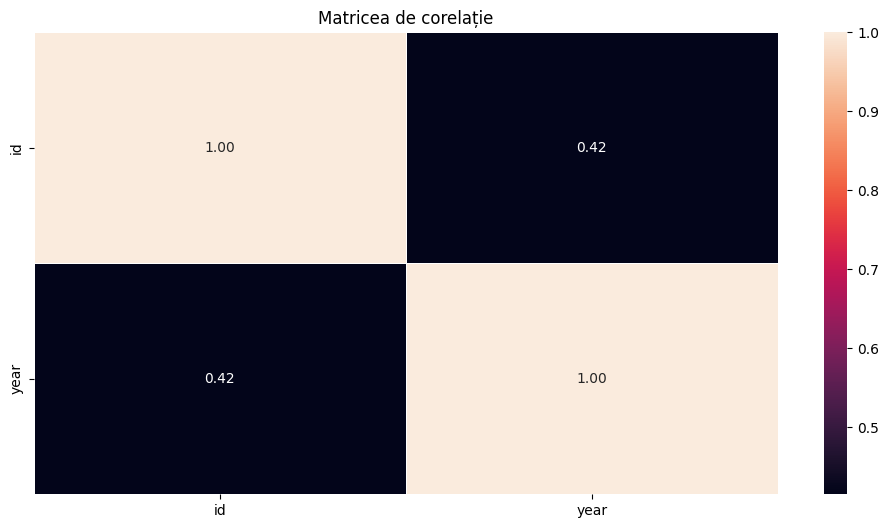

In [54]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', linewidths=0.5)
plt.title('Matricea de corelație')
plt.show()

<Axes: xlabel='gender', ylabel='count'>

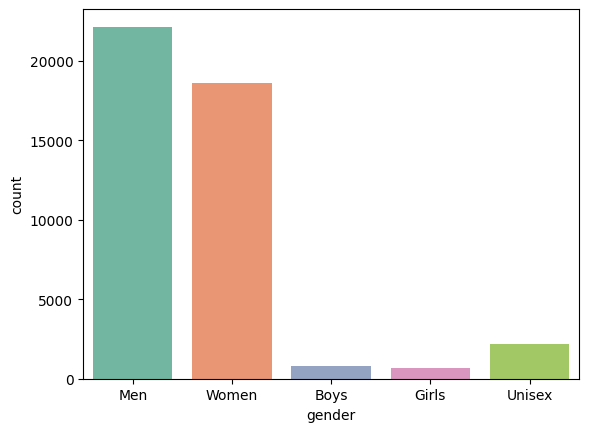

In [55]:
sns.countplot(data=df, x='gender',  palette='Set2')

<Axes: xlabel='season', ylabel='count'>

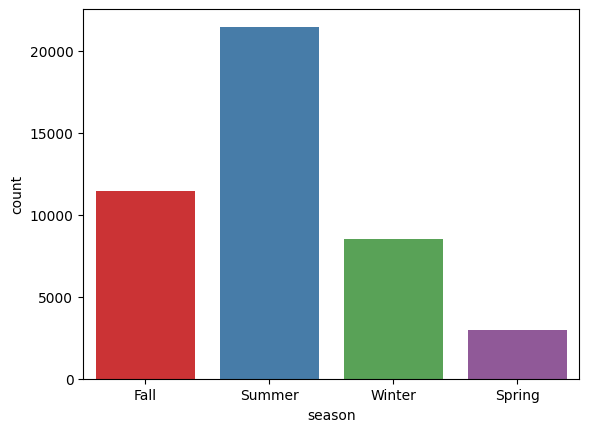

In [56]:
sns.countplot(data=df, x='season',  palette='Set1')

<Axes: xlabel='count', ylabel='masterCategory'>

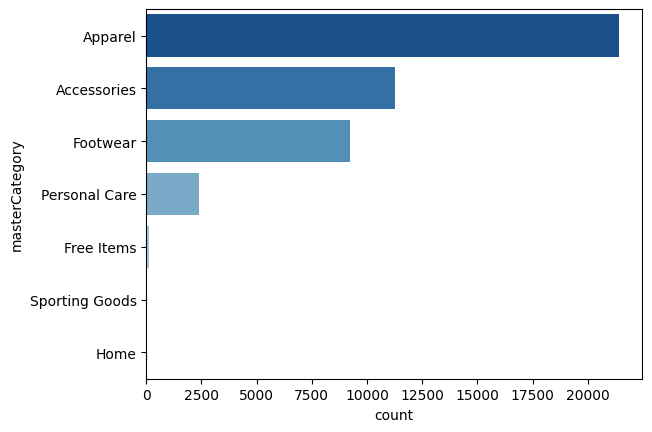

In [57]:
sns.countplot(data=df, y='masterCategory',
              order=df['masterCategory'].value_counts().index,
              palette='Blues_r')

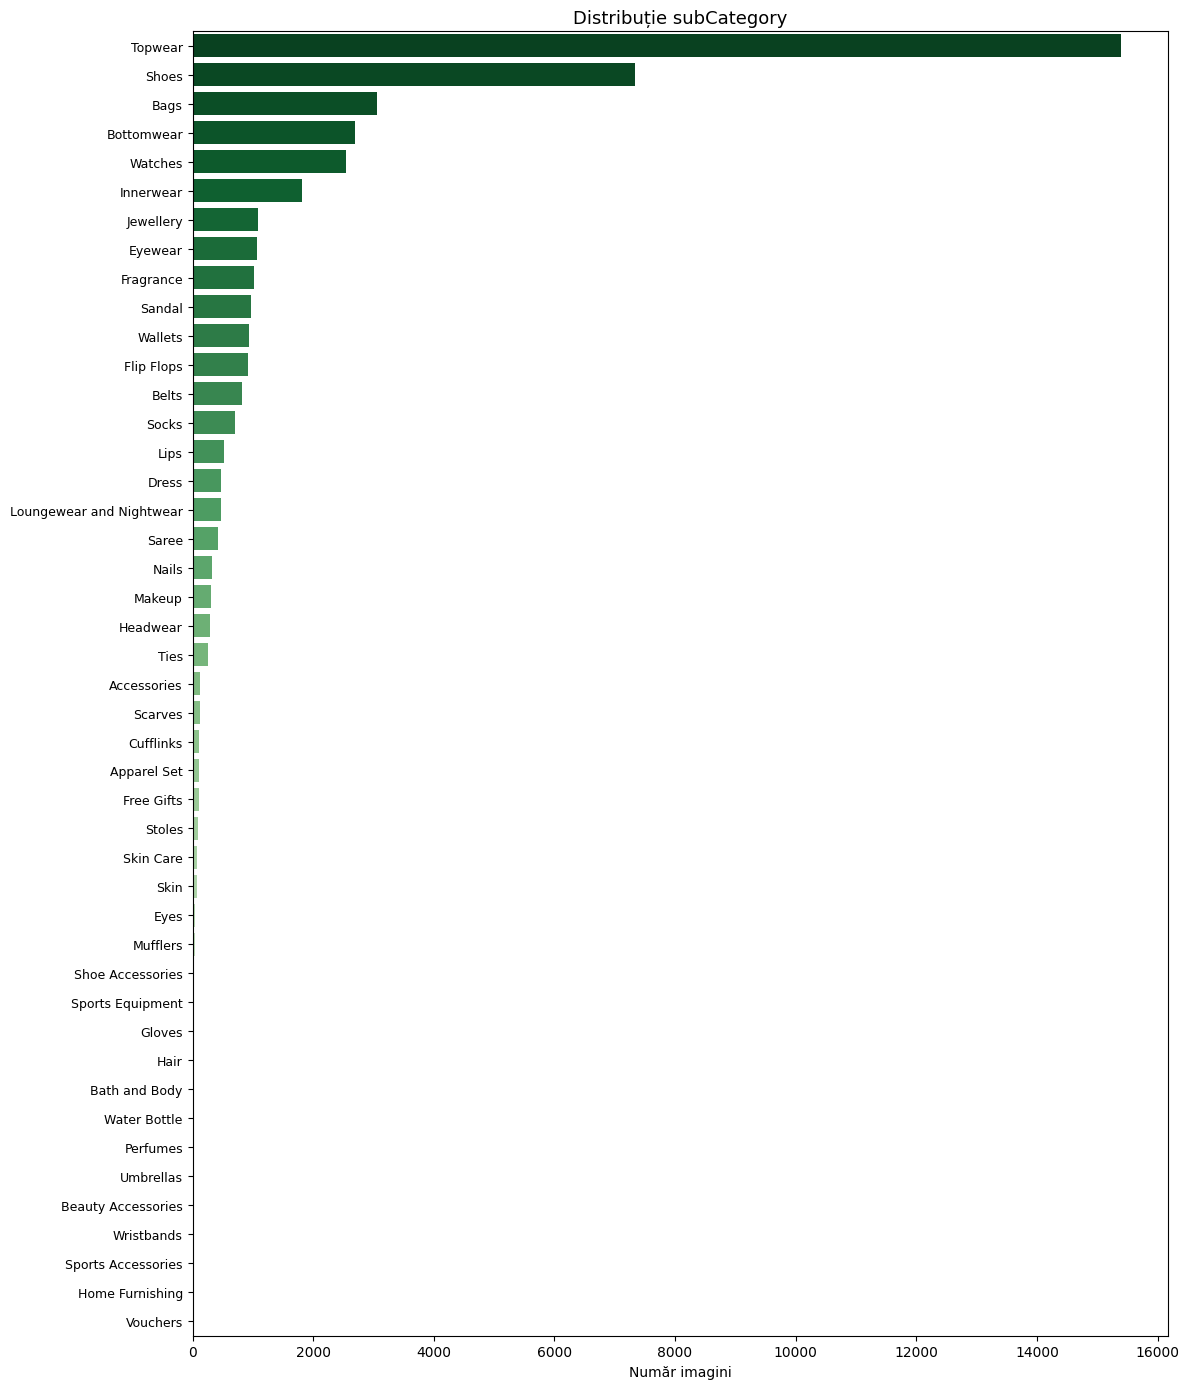

In [58]:
plt.figure(figsize=(12, 14))
sns.countplot(data=df, y='subCategory',
              order=df['subCategory'].value_counts().index,
              palette='Greens_r')
plt.title('Distribuție subCategory', fontsize=13)
plt.xlabel('Număr imagini')
plt.ylabel('')
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

<Axes: >

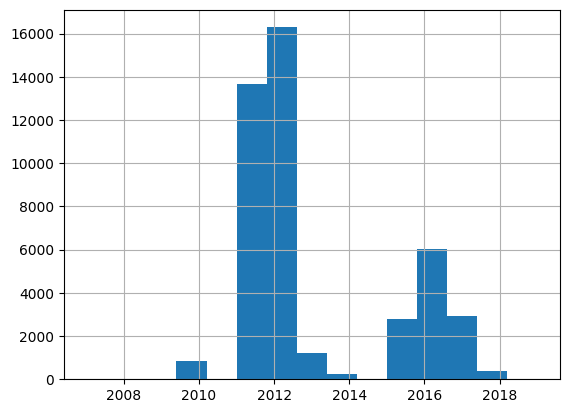

In [59]:
df['year'].hist(bins=15)

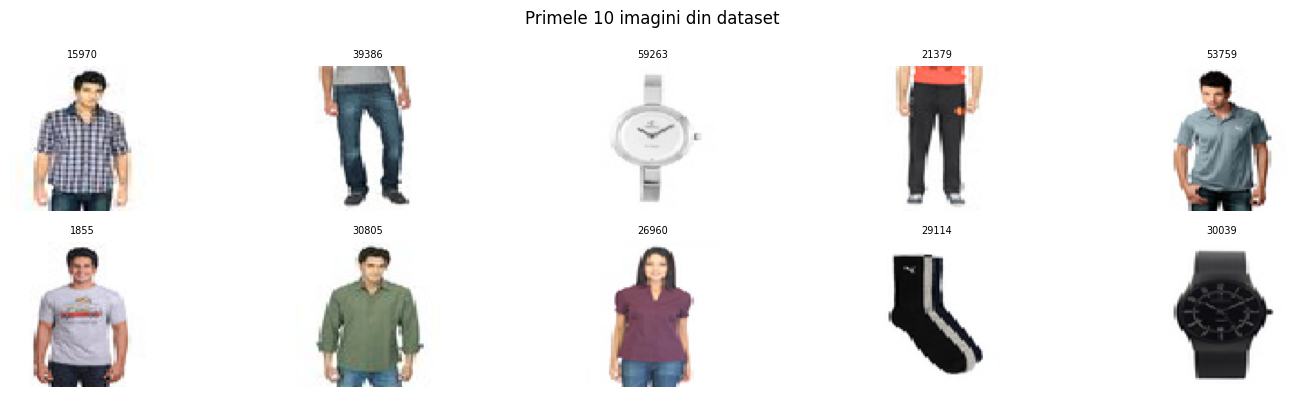

In [60]:
plt.figure(figsize=(15, 4))
for i, row in df.head(10).iterrows():
    img_path = os.path.join(Data_img, str(row['id']) + ".jpg")
    if os.path.exists(img_path):
        img = load_img(img_path, target_size=(80, 80))
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(str(row['id']), fontsize=7)
        plt.axis('off')
plt.suptitle('Primele 10 imagini din dataset')
plt.tight_layout()
plt.show()

# Shuffle the images in the dataset to prevent the network from training on only one specific type of image at a time

In [61]:
#filter only topweat and bottomwear
df_binary = df[df['subCategory'].isin(['Topwear','Bottomwear'])].copy()
df_binary['full_path'] = df_binary['id'].astype(str).apply(
    lambda x: os.path.join(Data_img, x + ".jpg"))

In [ ]:
df_binary = df_binary[df_binary['full_path'].apply(os.path.exists)].reset_index(drop=True)
print(f"\nImagini găsite: {len(df_binary)}")
print(df_binary['subCategory'].value_counts())


Imagini găsite: 18091
subCategory
Topwear       15398
Bottomwear     2693
Name: count, dtype: int64


In [ ]:
#shuffle img
df_binary = df_binary.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nDataset amestecat, primele 5 rânduri:")
print(df_binary[['id', 'subCategory']].head())


Dataset amestecat, primele 5 rânduri:
      id subCategory
0  22212     Topwear
1  19516     Topwear
2  16380  Bottomwear
3   9173  Bottomwear
4   6784     Topwear


# Decode the image data

In [64]:
IMG_SIZE = (80, 80)

In [ ]:
def decode_image(img_path):
    """Citește și normalizează o imagine."""
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0 
    return img_array

In [ ]:
X = np.array([decode_image(path) for path in df_binary['full_path']])
print(f"Shape date intrare: {X.shape}")

Shape date intrare: (18091, 80, 80, 3)


# Extract the labels and encode them as numerical values: 0 and 1 (for binary classification)

In [67]:
# Topwear = 0, Bottomwear = 1
label_map = {'Topwear': 0, 'Bottomwear': 1}
y = df_binary['subCategory'].map(label_map).values

print(f"\nEtichete unice: {np.unique(y)}")
print(f"Topwear (0): {np.sum(y == 0)} img")
print(f"Bottomwear (1): {np.sum(y == 1)} img")


Etichete unice: [0 1]
Topwear (0): 15398 img
Bottomwear (1): 2693 img


# The training and validation sets

In [68]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nSet de antrenament: {X_train.shape[0]} imagini")
print(f"Set de testare:     {X_test.shape[0]} imagini")


Set de antrenament: 14472 imagini
Set de testare:     3619 imagini


# Display an example of each category to verify correct data loading

In [69]:
plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

(np.float64(-0.5), np.float64(79.5), np.float64(79.5), np.float64(-0.5))

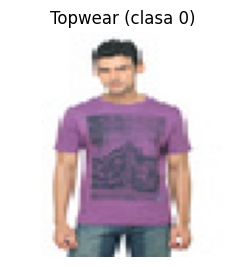

In [ ]:
# A 'Topwear' example (Class 0)
idx_top = np.where(y_train == 0)[0][0]
plt.subplot(1, 2, 1)
plt.imshow(X_train[idx_top])
plt.title('Topwear (clasa 0)')
plt.axis('off')

(np.float64(-0.5), np.float64(79.5), np.float64(79.5), np.float64(-0.5))

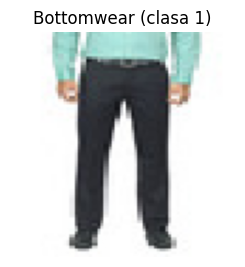

In [ ]:
# A 'Bottomwear' example (Class 1)
idx_bot = np.where(y_train == 1)[0][0]
plt.subplot(1, 2, 2)
plt.imshow(X_train[idx_bot])
plt.title('Bottomwear (clasa 1)')
plt.axis('off')

# Create the Convolutional Neural Network (CNN) model

In [72]:
model = Sequential()

In [73]:
# Block 1
model.add(Conv2D(input_shape=(80, 80, 3), padding='same', filters=32, kernel_size=(7, 7)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

In [74]:
# Block 2
model.add(Conv2D(filters=64, padding='valid', kernel_size=(5, 5)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

In [75]:
#Block 3
model.add(Conv2D(filters=128, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Dropout(0.2))
 
# Block 4
model.add(Conv2D(filters=256, padding='valid', kernel_size=(3, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

In [76]:
model.add(GlobalMaxPool2D())
model.add(Dense(units=256))
model.add(Activation('relu'))
model.add(Dropout(0.2))

In [ ]:
# Final layer
model.add(Dense(units=1))
model.add(Activation('sigmoid'))

# Display the model architecture summary

In [78]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 80, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 80, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 36, 36, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 36, 36, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,084,097 (4.14 MB)

 Trainable params: 1,082,625 (4.13 MB)

 Non-trainable params: 1,472 (5.75 KB)

# Model compilation and training execution

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [80]:
print("Model Training")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Model Training
Epoch 1/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 101s 241ms/step - accuracy: 0.9651 - loss: 0.1164 - val_accuracy: 0.9579 - val_loss: 0.1266
Epoch 2/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 100s 245ms/step - accuracy: 0.9877 - loss: 0.0396 - val_accuracy: 0.9862 - val_loss: 0.0363
Epoch 3/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 97s 239ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0.9827 - val_loss: 0.0512
Epoch 4/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 107s 262ms/step - accuracy: 0.9917 - loss: 0.0261 - val_accuracy: 0.9890 - val_loss: 0.0266
Epoch 5/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 115s 283ms/step - accuracy: 0.9928 - loss: 0.0211 - val_accuracy: 0.9910 - val_loss: 0.0217
Epoch 6/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 114s 279ms/step - accuracy: 0.9936 - loss: 0.0203 - val_accuracy: 0.9855 - val_loss: 0.0514
Epoch 7/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 111s 274ms/step - accuracy: 0.9950 - loss: 0.0148 - val_accuracy: 0.9696 - val_loss: 0.0722
Epoch 8/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 116s 285ms/step - accu

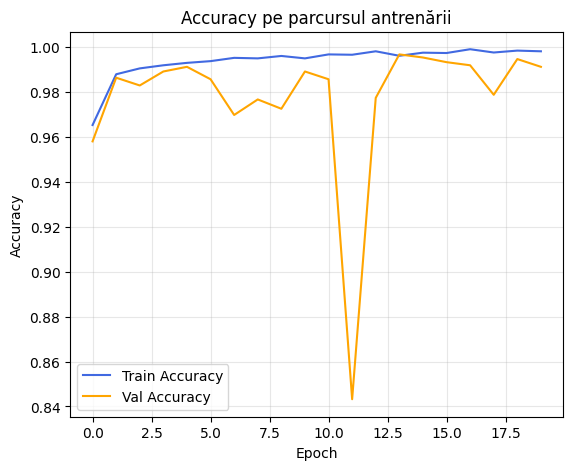

In [ ]:
plt.figure(figsize=(14, 5))
 
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='royalblue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
plt.title('Accuracy pe parcursul antrenării')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

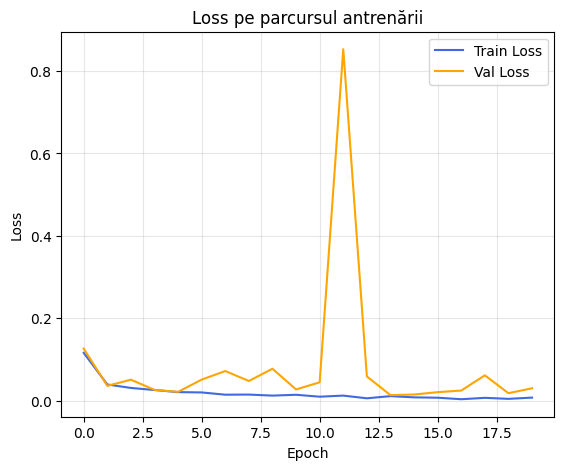

In [82]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='orange')
plt.title('Loss pe parcursul antrenării')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Assess model performance and metrics

In [83]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Test Loss:     0.0442
Test Accuracy: 0.9892 (98.92%)


In [ ]:
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Topwear', 'Bottomwear']))

114/114 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step

Classification Report:
              precision    recall  f1-score   support

     Topwear       0.99      0.99      0.99      3080
  Bottomwear       0.97      0.96      0.96       539

    accuracy                           0.99      3619
   macro avg       0.98      0.98      0.98      3619
weighted avg       0.99      0.99      0.99      3619



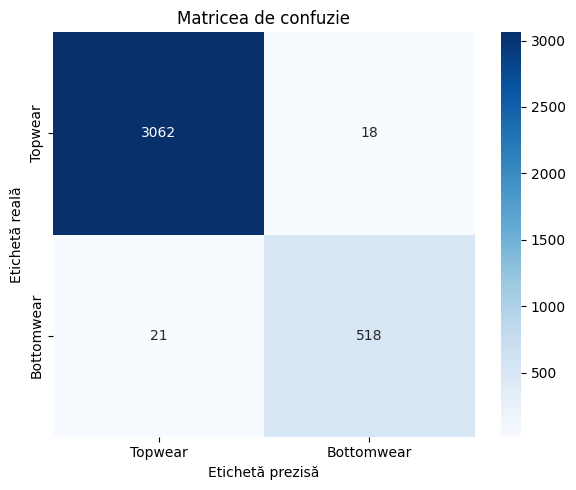

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Topwear', 'Bottomwear'],
            yticklabels=['Topwear', 'Bottomwear'])
plt.title('Matricea de confuzie')
plt.ylabel('Etichetă reală')
plt.xlabel('Etichetă prezisă')
plt.tight_layout()
plt.show()

In [ ]:
# ResNet50 vs MobileNetV2
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

def build_transfer_model(base_model_fn, model_name):
    base = base_model_fn(weights='imagenet', include_top=False,
                         input_shape=(80, 80, 3))
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=out, name=model_name)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


In [87]:
#ResNet50
resnet_model = build_transfer_model(ResNet50, "ResNet50")
history_resnet = resnet_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
resnet_loss, resnet_acc = resnet_model.evaluate(X_test, y_test, verbose=0)
print(f"ResNet50. Accuracy: {resnet_acc*100:.2f}%")

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 122s 287ms/step - accuracy: 0.9436 - loss: 0.1479 - val_accuracy: 0.9758 - val_loss: 0.0644
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 119s 291ms/step - accuracy: 0.9707 - loss: 0.0836 - val_accuracy: 0.9855 - val_loss: 0.0514
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 111s 272ms/step - accuracy: 0.9743 - loss: 0.0706 - val_accuracy: 0.9841 - val_loss: 0.0529
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 118s 290ms/step - accuracy: 0.9775 - loss: 0.0646 - val_accuracy: 0.9855 - val_loss: 0.0501
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 110s 270ms/step - accuracy: 0.9797 - loss: 0.0595 - val_accuracy: 0.9869 - val_loss: 0.0484
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 105s 257ms/step - accuracy: 0.9809 - loss: 0.0565 - val_accuracy: 0.9869 - val_loss: 0.0518
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 122s 301ms/step - accuracy: 0.9819 - loss: 0.0549 - val_accuracy: 0.9869 - val_loss: 0.0475
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 102s 250ms/step - accuracy: 0.9842 -

In [88]:
#MobileNetV2
mobile_model = build_transfer_model(MobileNetV2, "MobileNetV2")
history_mobile = mobile_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
mobile_loss, mobile_acc = mobile_model.evaluate(X_test, y_test, verbose=0)
print(f"MobileNetV2 . Accuracy: {mobile_acc*100:.2f}%")

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9721 - loss: 0.0897 - val_accuracy: 0.9848 - val_loss: 0.0399
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - accuracy: 0.9867 - loss: 0.0405 - val_accuracy: 0.9952 - val_loss: 0.0170
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9922 - loss: 0.0271 - val_accuracy: 0.9972 - val_loss: 0.0143
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 32s 78ms/step - accuracy: 0.9923 - loss: 0.0269 - val_accuracy: 0.9959 - val_loss: 0.0146
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - accuracy: 0.9924 - loss: 0.0233 - val_accuracy: 0.9959 - val_loss: 0.0131
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.9936 - loss: 0.0203 - val_accuracy: 0.9972 - val_loss: 0.0136
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 30s 74ms/step - accuracy: 0.9952 - loss: 0.0158 - val_accuracy: 0.9972 - val_loss: 0.0160
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 29s 71ms/step - accuracy: 0.9941 - loss: 0.0156 - 

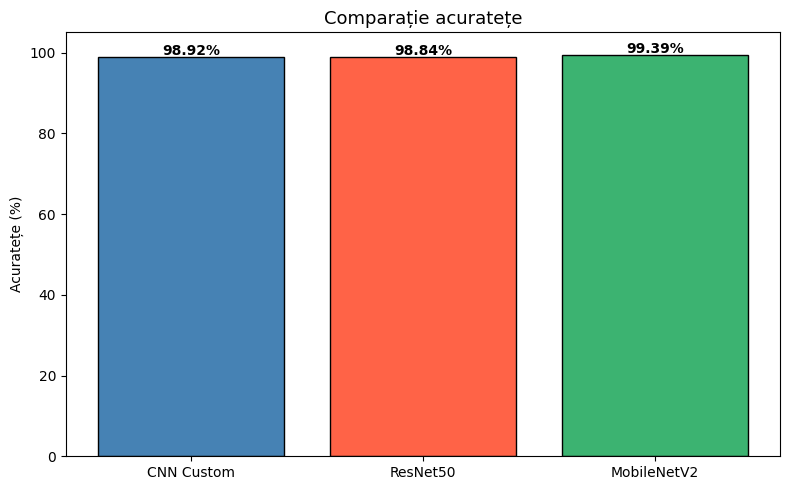


 SUMAR FINAL
  CNN Custom     : 98.92%
  ResNet50       : 98.84%
  MobileNetV2    : 99.39%


In [89]:
#grafic comparativ
cnn_loss, cnn_acc = model.evaluate(X_test, y_test, verbose=0)

modele  = ['CNN Custom', 'ResNet50', 'MobileNetV2']
acurateti = [cnn_acc*100, resnet_acc*100, mobile_acc*100]
culori    = ['steelblue', 'tomato', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(modele, acurateti, color=culori, edgecolor='black')
for bar, val in zip(bars, acurateti):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.2f}%', ha='center', fontweight='bold')
plt.title('Comparație acuratețe', fontsize=13)
plt.ylabel('Acuratețe (%)')
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print("\n SUMAR FINAL")
for nume, acc in zip(modele, acurateti):
    print(f"  {nume:15s}: {acc:.2f}%")

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

def predict_imagine(img_path):
    img = load_img(img_path, target_size=(80, 80))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictie = model.predict(img_array, verbose=0)[0][0]
    clasa = "Bottomwear" if predictie > 0.5 else "Topwear"
    incredere = predictie if predictie > 0.5 else 1 - predictie

    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(img_path, target_size=(80, 80)))
    plt.title(f"Clasă prezisă: {clasa}\nîncredere: {incredere*100:.1f}%",
              fontsize=12,
              color='green' if clasa == "Topwear" else 'blue')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Valoare sigmoid: {predictie:.4f}")
    print(f"Clasă prezisă  : {clasa}")
    print(f"Încredere      : {incredere*100:.1f}%")

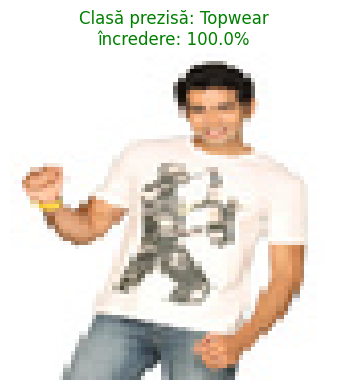

Valoare sigmoid: 0.0000
Clasă prezisă  : Topwear
Încredere      : 100.0%


In [ ]:
img_path = df_binary['full_path'].sample(1).values[0]
predict_imagine(img_path)

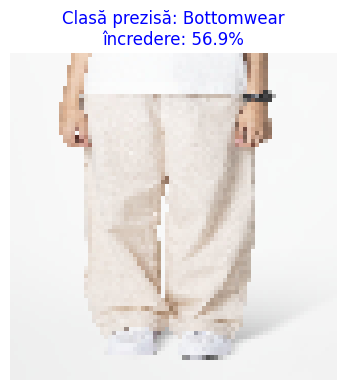

Valoare sigmoid: 0.5691
Clasă prezisă  : Bottomwear
Încredere      : 56.9%


In [93]:
predict_imagine("../data/new_img/pants_test.jpg")

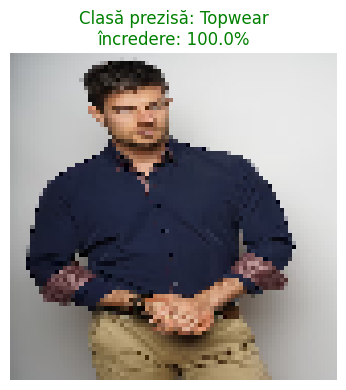

Valoare sigmoid: 0.0004
Clasă prezisă  : Topwear
Încredere      : 100.0%


In [94]:
predict_imagine("../data/new_img/shirt2_test.avif")

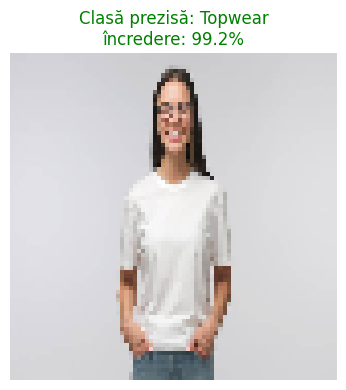

Valoare sigmoid: 0.0079
Clasă prezisă  : Topwear
Încredere      : 99.2%


In [95]:
predict_imagine("../data/new_img/shirt_woman_test.jpg")

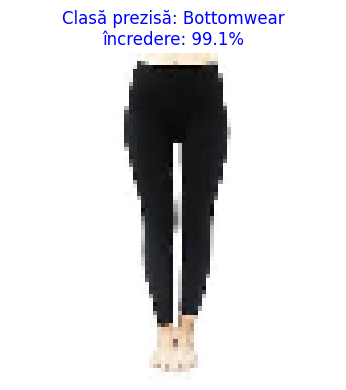

Valoare sigmoid: 0.9909
Clasă prezisă  : Bottomwear
Încredere      : 99.1%


In [96]:
predict_imagine("../data/new_img/leggings_test.jpg")